In [98]:
import pandas as pd
df=pd.read_csv("wdbc.data")

In [99]:
df.tail(5)

,842302,M,17.99,10.38,122.8,1001,0.1184,0.2776,0.3001,0.1471,...,25.38,17.33,184.6,2019,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
563,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
564,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
565,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
566,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400
567,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039


In [101]:
df.columns

Index(['842302', 'M', '17.99', '10.38', '122.8', '1001', '0.1184', '0.2776',
       '0.3001', '0.1471', '0.2419', '0.07871', '1.095', '0.9053', '8.589',
       '153.4', '0.006399', '0.04904', '0.05373', '0.01587', '0.03003',
       '0.006193', '25.38', '17.33', '184.6', '2019', '0.1622', '0.6656',
       '0.7119', '0.2654', '0.4601', '0.1189'],
      dtype='object')

In [103]:
df.isnull().sum()

842302      0
M           0
17.99       0
10.38       0
122.8       0
1001        0
0.1184      0
0.2776      0
0.3001      0
0.1471      0
0.2419      0
0.07871     0
1.095       0
0.9053      0
8.589       0
153.4       0
0.006399    0
0.04904     0
0.05373     0
0.01587     0
0.03003     0
0.006193    0
25.38       0
17.33       0
184.6       0
2019        0
0.1622      0
0.6656      0
0.7119      0
0.2654      0
0.4601      0
0.1189      0
dtype: int64

In [104]:
x=df.drop("M",axis=1)
y=df["M"]

In [105]:
import numpy as np
np.unique(y)

array(['B', 'M'], dtype=object)

In [106]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)  

In [107]:
#Normalizing or standardizing the features
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_scaled=scaler.fit_transform(x,y)

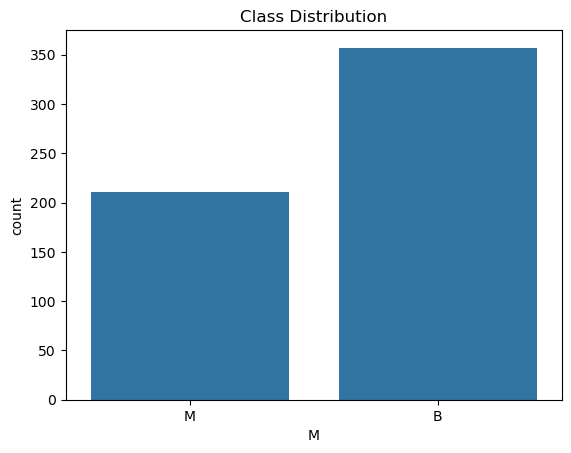

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="M",data=df)
plt.title("Class Distribution")
plt.show()

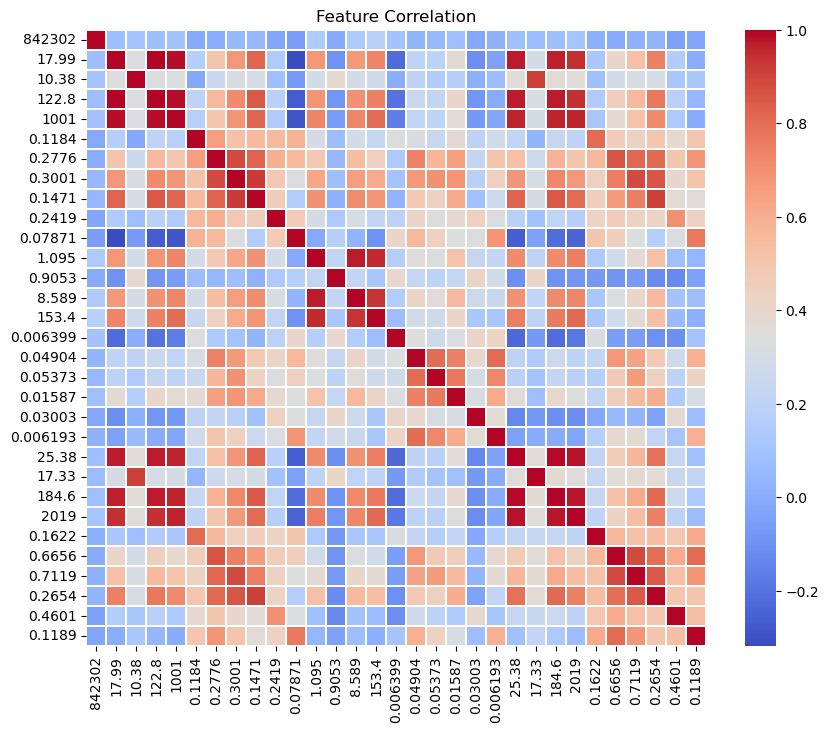

In [109]:
plt.figure(figsize=(10,8))
correlation_matrix=df.drop(columns='M').corr()
sns.heatmap(correlation_matrix,cmap="coolwarm",linewidths=0.2,cbar=True)
plt.title("Feature Correlation")
plt.show()

In [110]:
#splitting data
from sklearn.model_selection import train_test_split,GridSearchCV,cross_val_score
x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,random_state=42)

In [111]:
from sklearn.tree import DecisionTreeClassifier
from IPython.display import display
dt = DecisionTreeClassifier(random_state=42)
dt_params = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 8, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}
scoring = {"accuracy": "accuracy", "f1": "f1"}
dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=5,
    scoring=scoring,
    refit="f1"
)
dt_grid.fit(x_train, y_train)
dt_results = pd.DataFrame(dt_grid.cv_results_)

dt_table = dt_results[
    ["param_criterion", "param_max_depth",
     "mean_test_accuracy", "mean_test_f1"]
].rename(columns={
    "param_criterion": "criterion",
    "param_max_depth": "max_depth",
    "mean_test_accuracy": "Accuracy",
    "mean_test_f1": "F1 Score"
})
print("TABLE 1 – Decision Tree")
display(dt_table)



TABLE 1 – Decision Tree


,criterion,max_depth,Accuracy,F1 Score
0,gini,None,0.909670,0.876279
1,gini,None,0.909670,0.876279
2,gini,None,0.920733,0.888148
3,gini,None,0.920733,0.888148
4,gini,5,0.922906,0.894242
5,gini,5,0.922906,0.893168
6,gini,5,0.918535,0.885238
7,gini,5,0.918535,0.885238
8,gini,8,0.909670,0.876279
9,gini,8,0.909670,0.876279


In [112]:
#AdaBoost
from sklearn.ensemble import AdaBoostClassifier,GradientBoostingClassifier,RandomForestClassifier,StackingClassifier
ada = AdaBoostClassifier(random_state=42)
ada_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 1.0]
}
ada_grid = GridSearchCV(
    ada,
    ada_params,
    cv=5,
    scoring=scoring,
    refit="f1"
)
ada_grid.fit(x_train, y_train)
ada_results = pd.DataFrame(ada_grid.cv_results_)
ada_table = ada_results[
    ["param_n_estimators", "param_learning_rate",
     "mean_test_accuracy", "mean_test_f1"]
].rename(columns={
    "param_n_estimators": "n_estimators",
    "param_learning_rate": "learning_rate",
    "mean_test_accuracy": "Accuracy",
    "mean_test_f1": "F1 Score"
})
print("\nTABLE 2 – AdaBoost")
display(ada_table)



TABLE 2 – AdaBoost


,n_estimators,learning_rate,Accuracy,F1 Score
0,50,0.01,0.918437,0.885481
1,100,0.01,0.927326,0.897981
2,200,0.01,0.942759,0.918615
3,50,0.10,0.958144,0.941313
4,100,0.10,0.960342,0.943722
5,200,0.10,0.966984,0.953028
6,50,1.00,0.966984,0.952784
7,100,1.00,0.969182,0.955393
8,200,1.00,0.969182,0.954951


In [113]:
#Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "subsample": [0.8, 1.0]
}
gb_grid = GridSearchCV(
    gb,
    gb_params,
    cv=5,
    scoring=scoring,
    refit="f1"
)
gb_grid.fit(x_train, y_train)
gb_results = pd.DataFrame(gb_grid.cv_results_)
gb_table = gb_results[
    ["param_n_estimators", "param_learning_rate", "param_max_depth",
     "mean_test_accuracy", "mean_test_f1"]
].rename(columns={
    "param_n_estimators": "n_estimators",
    "param_learning_rate": "learning_rate",
    "param_max_depth": "max_depth",
    "mean_test_accuracy": "Accuracy",
    "mean_test_f1": "F1 Score"
})
print("\nTABLE 3 – Gradient Boosting")
display(gb_table)


TABLE 3 – Gradient Boosting


,n_estimators,learning_rate,max_depth,Accuracy,F1 Score
0,100,0.05,3,0.958193,0.940438
1,100,0.05,3,0.951526,0.932457
2,200,0.05,3,0.958193,0.940835
3,200,0.05,3,0.953748,0.935131
4,100,0.05,5,0.955946,0.937272
5,100,0.05,5,0.938291,0.913927
6,200,0.05,5,0.955971,0.937060
7,200,0.05,5,0.938291,0.913591
8,100,0.10,3,0.962589,0.946579
9,100,0.10,3,0.953748,0.935131


In [119]:
#XGBoost
xgb = XGBClassifier(
    eval_metric="logloss",
    random_state=42
)
xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "gamma": [0, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=5,
    scoring=scoring,
    refit="f1"
)
xgb_grid.fit(x_train, y_train)
xgb_results = pd.DataFrame(xgb_grid.cv_results_)
xgb_table = xgb_results[
    ["param_n_estimators", "param_learning_rate",
     "param_max_depth", "param_gamma",
     "mean_test_accuracy", "mean_test_f1"]
].rename(columns={
    "param_n_estimators": "n_estimators",
    "param_learning_rate": "learning_rate",
    "param_max_depth": "max_depth",
    "param_gamma": "gamma",
    "mean_test_accuracy": "Accuracy",
    "mean_test_f1": "F1 Score"
})
print("\nTABLE 4 – XGBoost")
display(xgb_table)


TABLE 4 – XGBoost


,n_estimators,learning_rate,max_depth,gamma,Accuracy,F1 Score
0,100,0.05,3,0.0,0.966960,0.953809
1,100,0.05,3,0.0,0.964762,0.950995
2,200,0.05,3,0.0,0.962564,0.947058
3,200,0.05,3,0.0,0.966960,0.953857
4,100,0.05,5,0.0,0.960342,0.944456
...,...,...,...,...,...,...
59,200,0.10,3,0.1,0.966960,0.953857
60,100,0.10,5,0.1,0.966960,0.953809
61,100,0.10,5,0.1,0.966960,0.953500
62,200,0.10,5,0.1,0.969182,0.956570


In [116]:
#Random Forest
rf = RandomForestClassifier(random_state=42)
rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 15, 20],
    "criterion": ["gini", "entropy"]
}
rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=5,
    scoring=scoring,
    refit="f1"
)
rf_grid.fit(x_train, y_train)
rf_results = pd.DataFrame(rf_grid.cv_results_)
rf_table = rf_results[
    ["param_n_estimators", "param_max_depth", "param_criterion",
     "mean_test_accuracy", "mean_test_f1"]
].rename(columns={
    "param_n_estimators": "n_estimators",
    "param_max_depth": "max_depth",
    "param_criterion": "criterion",
    "mean_test_accuracy": "Accuracy",
    "mean_test_f1": "F1 Score"
})
print("\nTABLE 5 – Random Forest")
display(rf_table)


TABLE 5 – Random Forest


,n_estimators,max_depth,criterion,Accuracy,F1 Score
0,100,None,gini,0.953748,0.935194
1,200,None,gini,0.955922,0.938319
2,300,None,gini,0.955922,0.938319
3,100,15,gini,0.953748,0.935194
4,200,15,gini,0.955922,0.938319
5,300,15,gini,0.955922,0.938319
6,100,20,gini,0.953748,0.935194
7,200,20,gini,0.955922,0.938319
8,300,20,gini,0.955922,0.938319
9,100,None,entropy,0.958120,0.941393


In [117]:
#STACKED ENSEMBLE MODEL
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import StackingClassifier
stack_configs = [
    (
        [("svm", SVC(probability=True)),
         ("nb", GaussianNB()),
         ("dt", DecisionTreeClassifier(random_state=42))],
        LogisticRegression()
    ),
    (
        [("svm", SVC(probability=True)),
         ("nb", GaussianNB()),
         ("dt", DecisionTreeClassifier(random_state=42))],
        RandomForestClassifier(n_estimators=100, random_state=42)
    ),
    (
        [("svm", SVC(probability=True)),
         ("dt", DecisionTreeClassifier(random_state=42)),
         ("knn", KNeighborsClassifier())],
        LogisticRegression()
    )
]
stack_results = []
for base_models, final_model in stack_configs:
    stack = StackingClassifier(
        estimators=base_models,
        final_estimator=final_model,
        cv=5
    )
    stack.fit(x_train, y_train)
    y_pred = stack.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    stack_results.append([
        ", ".join([name for name, _ in base_models]),
        type(final_model).__name__,
        acc,
        f1
    ])
table6 = pd.DataFrame(
    stack_results,
    columns=["Base Models", "Final Estimator", "Accuracy", "F1 Score"]
)

print("TABLE 6: Stacked Ensemble - Hyperparameter Tuning")
display(table6)


TABLE 6: Stacked Ensemble - Hyperparameter Tuning


,Base Models,Final Estimator,Accuracy,F1 Score
0,"svm, nb, dt",LogisticRegression,0.964912,0.954545
1,"svm, nb, dt",RandomForestClassifier,0.964912,0.955556
2,"svm, dt, knn",LogisticRegression,0.964912,0.954545


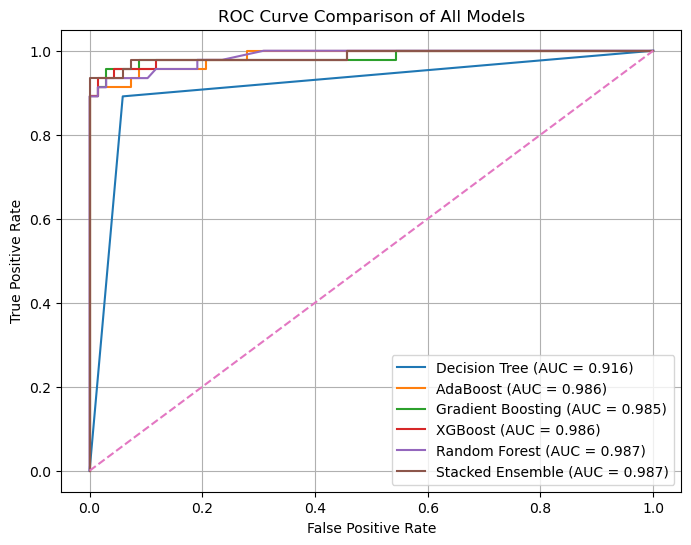

In [118]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
models = {
    "Decision Tree": dt_grid.best_estimator_,
    "AdaBoost": ada_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_,
    "Random Forest": rf_grid.best_estimator_,
    "Stacked Ensemble": stack
}
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of All Models")
plt.legend()
plt.grid(True)
plt.show()


In [121]:
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, x_train, y_train, cv=5, scoring="accuracy")
    cv_results.append([name,scores[0],scores[1],scores[2],scores[3],scores[4],np.mean(scores)])


In [122]:
table7 = pd.DataFrame(
    cv_results,columns=["Model", "Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5", "Average Accuracy"])
table7 = table7.round(4)
print("TABLE 7: 5-Fold Cross Validation Results for All Models")
display(table7)

TABLE 7: 5-Fold Cross Validation Results for All Models


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average Accuracy
0,Decision Tree,0.9451,0.956,0.9451,0.9231,0.9111,0.9361
1,AdaBoost,1.0000,0.978,0.9670,0.9231,0.9778,0.9692
2,Gradient Boosting,0.9780,0.978,0.9560,0.9451,0.9778,0.9670
3,XGBoost,0.9890,0.989,0.9780,0.9341,0.9667,0.9714
4,Random Forest,0.9780,0.989,0.9560,0.9231,0.9444,0.9581
5,Stacked Ensemble,0.9890,0.978,0.9780,0.9451,0.9556,0.9691


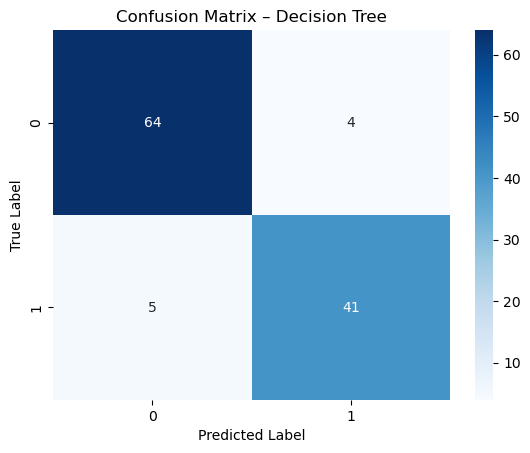

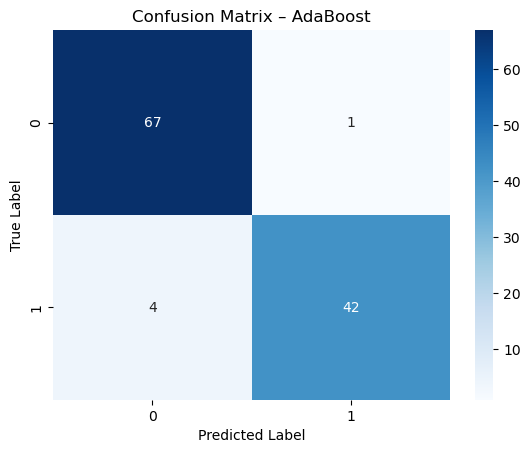

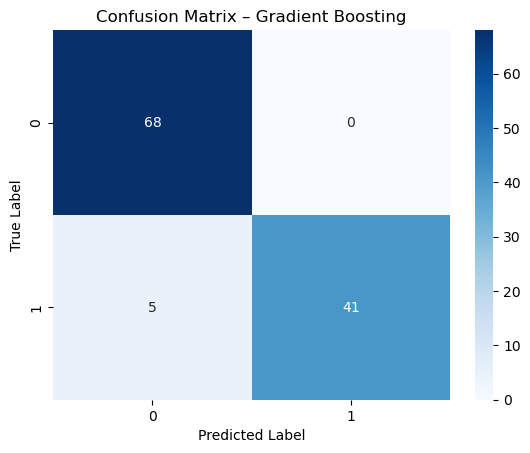

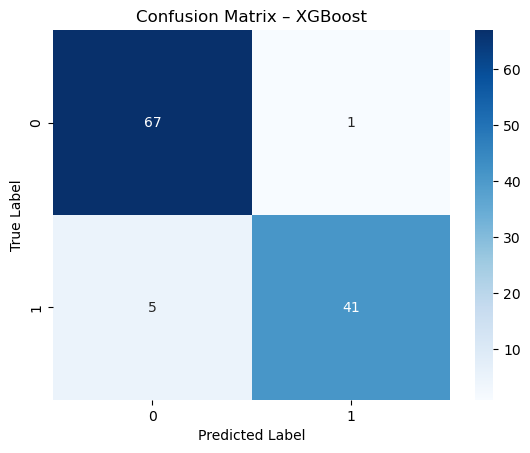

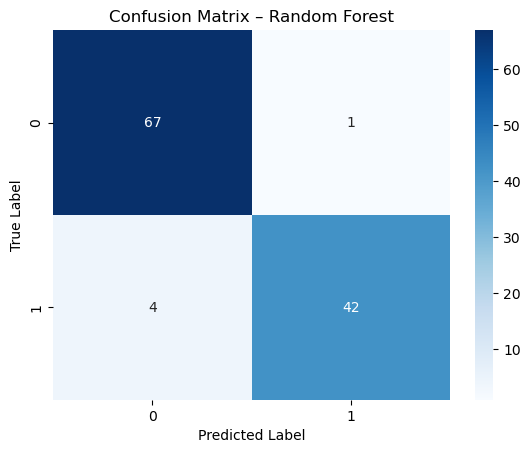

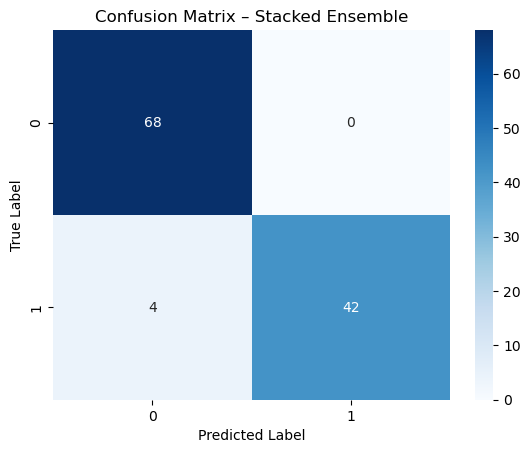

In [123]:
from sklearn.metrics import confusion_matrix
for name, model in models.items():
    y_pred = model.predict(x_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()